[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sk-2103/AI4Sustainability-Labs/blob/main/labs/lab05_lstm_streamflow/lab05_lstm_streamflow.ipynb)  
**AI for Sustainability** · University of Wisconsin–Madison · Labs by Saurabh Kaushik · Course instructor: Dr. Beth Tellman  
*Make a copy (File → Save a copy in Drive) before you start. Part of the [AI for Sustainability lab series](https://github.com/Sk-2103/AI4Sustainability-Labs).*

# Lab 05 — LSTM for Streamflow Discharge Forecasting
### AI for Sustainability | University of Wisconsin–Madison

---

> *"Water flows downhill, but forecasting it requires looking back in time."*

---
- Change runtime type to GPU (Runtime → Change runtime type → T4 GPU)


## 🎯 Learning Objectives

By the end of this lab, you will be able to:

1. Explain **why sequential data requires special architectures** — and why standard ANNs fail
2. Describe the **internal mechanics of an LSTM cell**: forget gate, input gate, output gate, cell state
3. Download and parse **real USGS streamflow data** using the `dataretrieval` Python package
4. Prepare **time-series data** for LSTM training using sliding windows and chronological splits
5. Build and train an **LSTM model in PyTorch** for next-day discharge prediction
6. Evaluate model performance with **hydrological metrics** (NSE, KGE, PBIAS)
7. Visualize **hydrographs and diagnostics** like a practicing hydrologist

---

## 🌊 Real Dataset — USGS Gauge 05397500
### Wisconsin River at Merrill, WI

We use **official daily streamflow data** from a USGS stream gauge on the Wisconsin River, downloaded live via the USGS National Water Information System (NWIS) API — the same data source used in professional hydrology research.

| Detail | Value |
|--------|-------|
| **Station name** | Wisconsin River at Merrill, WI |
| **USGS Site ID** | 05397500 |
| **Drainage area** | ~4,270 km² |
| **Latitude / Longitude** | 45.18°N, 89.68°W |
| **Record length used** | 2000–2019 (20 years, ~7,300 days) |
| **Target variable** | Mean daily discharge (cfs → converted to m³/s) |
| **Forcing data** | DAYMET: daily precip, Tmax, Tmin, dayl, swe |

📍 This gauge is ~90 miles north of UW–Madison in a watershed representative of Wisconsin's mixed forest/agriculture landscape with strong snowmelt signals.

---

## 📚 Pre-Lab Reading (Before Class)

| Resource | URL | Time |
|----------|-----|------|
| Colah's LSTM Guide (must-read!) | https://colah.github.io/posts/2015-08-Understanding-LSTMs/ | 20 min |
| Kratzert et al. 2018 — LSTM beats process models | https://doi.org/10.5194/hess-22-6005-2018 | 30 min |
| USGS NWIS — Wisconsin River gauge | https://waterdata.usgs.gov/monitoring-location/05397500/ | 5 min |
| dataretrieval Python docs | https://doi-usgs.github.io/dataretrieval-python/ | 10 min |
| PyTorch nn.LSTM docs | https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html | 10 min |


---
# Part 0 — Setup & Imports

In [ ]:
# ── Install packages (run once on Colab or first-time local) ──────
!pip install torch dataretrieval numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")
print(f"✅ PyTorch: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.1 MB/s eta 0:00:00
✅ Device : cuda
✅ PyTorch: 2.10.0+cu128


---
# Part 1 — Why Sequence Matters in Hydrology

## 1.1 The Rainfall–Runoff Process

When rain falls on a watershed, it doesn't instantly appear in the river. Water travels through multiple **slow storage compartments**:

```
  🌧️ Rainfall / ❄️ Snowmelt
         │
         ├──► Surface runoff        (minutes → hours)
         ├──► Shallow subsurface    (hours → days)
         ├──► Deep soil moisture    (days → weeks)
         └──► Groundwater          (weeks → months)
                        │
                        ▼
               🏞️ River Discharge Q(t)
```

**Key insight:** Today's river discharge Q(t) depends on rainfall from **many past days**. Standard ANN has no memory. LSTM is built exactly for this.

## 1.2 Why Standard ANNs Fail for Sequences

| Network | Memory | Good for hydrology? |
|---------|--------|---------------------|
| Feedforward ANN | ❌ None | ❌ Treats each day independently |
| RNN | ✅ Short | ⚠️ Suffers vanishing gradients |
| **LSTM** | ✅ **Long + Short** | ✅ **Designed for this!** |
| Transformer | ✅ Full sequence | ✅ But needs more data |

## 1.3 The Vanishing Gradient Problem (Why RNNs Fail)

In a standard RNN, gradients are multiplied through time during backpropagation:
$$\frac{\partial L}{\partial W} = \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

Each term is typically $< 1$, so after $T$ steps this product **vanishes to near zero**. The network forgets events older than ~10 steps. In Wisconsin, snowpack from January still controls spring floods in April — that's 90+ days of memory needed!

### 📌 Resources
- [Colah's LSTM (visualized)](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [Hochreiter & Schmidhuber 1997 — original LSTM paper](https://www.bioinf.jku.at/publications/older/2604.pdf)

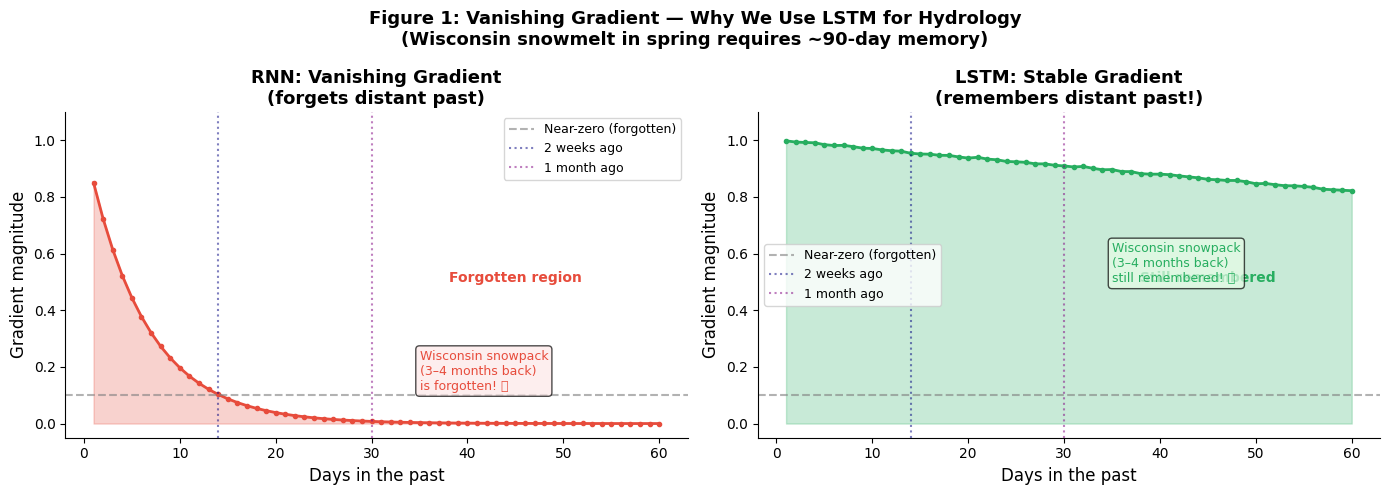

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 1 — Vanishing Gradient Illustration
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
timesteps = np.arange(1, 61)

# RNN: gradient decays exponentially
rnn_grad = 0.85 ** timesteps
# LSTM: gradient stays near 1 (gated cell state = constant error carousel)
lstm_grad = np.clip(1.0 - 0.003 * timesteps + 0.002 * np.random.randn(len(timesteps)), 0.7, 1.05)

for ax, grad, col, title, note in [
    (axes[0], rnn_grad, '#e74c3c', 'RNN: Vanishing Gradient\n(forgets distant past)', 'Forgotten region'),
    (axes[1], lstm_grad, '#27ae60', 'LSTM: Stable Gradient\n(remembers distant past!)', 'Still remembered')
]:
    ax.fill_between(timesteps, grad, alpha=0.25, color=col)
    ax.plot(timesteps, grad, 'o-', color=col, linewidth=2, markersize=3)
    ax.axhline(0.1, color='gray', linestyle='--', alpha=0.6, label='Near-zero (forgotten)')
    ax.axvline(14, color='navy', linestyle=':', alpha=0.5, label='2 weeks ago')
    ax.axvline(30, color='purple', linestyle=':', alpha=0.5, label='1 month ago')
    ax.set_xlabel('Days in the past', fontsize=12)
    ax.set_ylabel('Gradient magnitude', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.1)
    ax.spines[['top','right']].set_visible(False)
    ax.text(45, 0.5, note, ha='center', color=col, fontsize=10, fontweight='bold')

axes[0].text(35, 0.12, 'Wisconsin snowpack\n(3–4 months back)\nis forgotten! ❌', fontsize=9, color='#e74c3c',
             bbox=dict(boxstyle='round', facecolor='#fde8e8', alpha=0.7))
axes[1].text(35, 0.5, 'Wisconsin snowpack\n(3–4 months back)\nstill remembered! ✅', fontsize=9, color='#27ae60',
             bbox=dict(boxstyle='round', facecolor='#e8fde8', alpha=0.7))

fig.suptitle('Figure 1: Vanishing Gradient — Why We Use LSTM for Hydrology\n'
             '(Wisconsin snowmelt in spring requires ~90-day memory)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_vanishing_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2 — Loading Real USGS Streamflow Data

## 2.1 The `dataretrieval` Package

The USGS provides free, open-access streamflow data through the **National Water Information System (NWIS)**. The `dataretrieval` Python package makes it trivially easy to access this data programmatically — no account needed.

```python
from dataretrieval import nwis
dv, meta = nwis.get_dv(sites='05397500', start='2000-01-01', end='2019-12-31', parameterCd='00060')
#                                ↑ gauge ID      ↑ date range                              ↑ discharge code
```

| USGS Parameter Code | Variable |
|---------------------|----------|
| `00060` | Discharge (streamflow), mean daily (cfs) |
| `00065` | Gage height (ft) |
| `00010` | Water temperature (°C) |

## 2.2 Forcing Data — DAYMET

We also download meteorological forcing data (precipitation, temperature) from **DAYMET** — a gridded 1km daily climate dataset for North America, accessed via USGS.

### 📌 Resources
- [USGS dataretrieval docs](https://doi-usgs.github.io/dataretrieval-python/)
- [USGS NWIS gauge 05397500](https://waterdata.usgs.gov/monitoring-location/05397500/)
- [DAYMET dataset](https://daymet.ornl.gov/)
- [CAMELS US — benchmark dataset for LSTM hydrology](https://ral.ucar.edu/solutions/products/camels)

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DATA DOWNLOAD — USGS GAUGE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SITE_ID    = '05397500'
START_DATE = '2000-01-01'
END_DATE   = '2019-12-31'

def _parse_daymet(text):
    """
    Parse DAYMET single-pixel CSV robustly.
    Finds the header row dynamically instead of hardcoding skiprows.
    """
    from io import StringIO
    lines = text.splitlines()

    # Find the first line that contains 'year' — that's the header
    header_idx = None
    for i, line in enumerate(lines):
        if 'year' in line.lower() and 'yday' in line.lower():
            header_idx = i
            break

    if header_idx is None:
        # Print first 15 lines to help diagnose
        print("⚠️  Could not find header in DAYMET response. First 15 lines:")
        for i, l in enumerate(lines[:15]):
            print(f"   [{i:02d}] {l}")
        raise RuntimeError("DAYMET CSV header row not found — see lines printed above.")

    print(f"   DAYMET header found at line {header_idx}")
    forcing = pd.read_csv(StringIO(text), skiprows=header_idx)
    forcing.columns = forcing.columns.str.strip()
    return forcing


def load_usgs_data():
    """
    Download real USGS daily streamflow + DAYMET forcing data.
    Raises RuntimeError if any step fails — no synthetic fallback.
    """
    from dataretrieval import nwis
    import requests

    # ── Daily discharge ───────────────────────────────────────────
    print(f"📡 Downloading USGS discharge for site {SITE_ID}...")
    dv, meta = nwis.get_dv(
        sites=SITE_ID,
        start=START_DATE,
        end=END_DATE,
        parameterCd='00060'
    )
    if dv.empty:
        raise RuntimeError(
            f"USGS returned empty data for site {SITE_ID}.\n"
            f"Verify at: https://waterdata.usgs.gov/monitoring-location/{SITE_ID}/"
        )
    print(f"   ✅ {len(dv)} discharge records")

    dv.index = pd.to_datetime(dv.index).tz_localize(None)
    discharge_col = [c for c in dv.columns if '00060' in c and 'Mean' in c]
    if not discharge_col:
        raise RuntimeError(
            f"Discharge column not found. Available columns: {list(dv.columns)}\n"
            f"Expected a column containing '00060' and 'Mean'."
        )
    dv = dv.rename(columns={discharge_col[0]: 'discharge_cfs'})
    dv['discharge'] = dv['discharge_cfs'] * 0.028317
    dv = dv[['discharge']].copy()

    # ── Get lat/lon via USGS REST ─────────────────────────────────
    print(f"📡 Fetching site coordinates...")
    info_url = (f"https://waterservices.usgs.gov/nwis/site/"
                f"?format=rdb&sites={SITE_ID}&siteOutput=Expanded")
    r_info = requests.get(info_url, timeout=30)
    r_info.raise_for_status()

    lines = [l for l in r_info.text.splitlines()
             if not l.startswith('#') and l.strip()]
    if len(lines) < 3:
        raise RuntimeError(f"Could not parse site info for {SITE_ID}.")
    headers = lines[0].split('\t')
    values  = lines[2].split('\t')
    info    = dict(zip(headers, values))
    lat = float(info['dec_lat_va'])
    lon = float(info['dec_long_va'])
    print(f"   ✅ lat={lat:.4f}, lon={lon:.4f}")

    # ── DAYMET forcing ────────────────────────────────────────────
    print(f"📡 Downloading DAYMET meteorological forcing...")
    daymet_url = (
        f"https://daymet.ornl.gov/single-pixel/api/data"
        f"?lat={lat}&lon={lon}"
        f"&vars=prcp,tmax,tmin,swe,dayl"
        f"&start={START_DATE}&end={END_DATE}"
        f"&format=csv"
    )
    r = requests.get(daymet_url, timeout=60)
    r.raise_for_status()

    # Dynamically detect header — robust to DAYMET format changes
    forcing = _parse_daymet(r.text)

    forcing['date'] = pd.to_datetime(
        forcing['year'].astype(str) + '-' +
        forcing['yday'].astype(str).str.zfill(3),
        format='%Y-%j'
    )
    forcing = forcing.set_index('date')

    # Rename columns — strip units from names dynamically
    col_map = {}
    for c in forcing.columns:
        cl = c.lower()
        if 'prcp'  in cl: col_map[c] = 'prcp'
        elif 'tmax' in cl: col_map[c] = 'tmax'
        elif 'tmin' in cl: col_map[c] = 'tmin'
        elif 'swe'  in cl: col_map[c] = 'swe'
        elif 'dayl' in cl: col_map[c] = 'dayl'
    forcing = forcing.rename(columns=col_map)
    forcing = forcing[['prcp', 'tmax', 'tmin', 'swe', 'dayl']].copy()
    forcing['tmean'] = (forcing['tmax'] + forcing['tmin']) / 2
    print(f"   ✅ {len(forcing)} DAYMET records")

    # ── Merge ─────────────────────────────────────────────────────
    df = dv.join(forcing, how='inner').dropna()
    if len(df) < 365:
        raise RuntimeError(
            f"Merged dataset has only {len(df)} days — too short to train.\n"
            f"Check USGS/DAYMET date coverage for site {SITE_ID}."
        )

    print(f"\n🟢 Live data ready: {len(df)} days  "
          f"({df.index[0].date()} → {df.index[-1].date()})")
    return df


# ── Load ──────────────────────────────────────────────────────────
df = load_usgs_data()
print(f"\n📊 Dataset: {df.shape[0]} days × {df.shape[1]} variables")
df.head(8)

📡 Downloading USGS discharge for site 05397500...
   ✅ 7305 discharge records
📡 Fetching site coordinates...
   ✅ lat=44.9189, lon=-89.5519
📡 Downloading DAYMET meteorological forcing...
   DAYMET header found at line 6
   ✅ 7300 DAYMET records

🟢 Live data ready: 7300 days  (2000-01-01 → 2019-12-31)

📊 Dataset: 7300 days × 7 variables


,discharge,prcp,tmax,tmin,swe,dayl,tmean
2000-01-01,1.585752,6.72,1.10,-6.48,36.51,31187.53,-2.690
2000-01-02,1.529118,10.25,-0.40,-5.69,36.38,31237.98,-3.045
2000-01-03,1.529118,2.01,-2.52,-6.12,38.39,31292.54,-4.320
2000-01-04,1.472484,0.00,-4.80,-8.61,38.39,31351.17,-6.705
2000-01-05,1.472484,1.03,-3.37,-19.65,39.42,31413.82,-11.510
2000-01-06,1.529118,0.00,-2.19,-15.59,39.42,31480.45,-8.890
2000-01-07,1.472484,0.00,-6.56,-18.01,39.42,31551.00,-12.285
2000-01-08,1.529118,0.00,4.06,-15.28,39.42,31625.41,-5.610


In [ ]:
# ── Summary statistics ─────────────────────────────────────────────
print("📈 Summary Statistics — Wisconsin River at Merrill, WI")
print("=" * 60)
print(df.describe().round(3))
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Date range:    {df.index[0].date()} → {df.index[-1].date()}")
print(f"\nDischarge stats (m³/s):")
print(f"  Mean   : {df['discharge'].mean():.1f}")
print(f"  Median : {df['discharge'].median():.1f}")
print(f"  Max    : {df['discharge'].max():.1f}   (flood event)")
print(f"  Min    : {df['discharge'].min():.1f}   (summer low flow)")

📈 Summary Statistics — Wisconsin River at Merrill, WI
       discharge      prcp      tmax      tmin       swe       dayl     tmean
count   7300.000  7300.000  7300.000  7300.000  7300.000   7300.000  7300.000
mean       6.848     2.481    11.869     0.749    14.586  43200.144     6.309
std        9.975     5.840    12.610    11.526    27.896   8487.193    11.869
min        0.912     0.000   -26.510   -33.190     0.000  30913.110   -28.925
25%        2.265     0.000     1.360    -7.182     0.000  34938.870    -2.796
50%        3.455     0.000    13.020     1.420     0.000  43199.790     7.352
75%        6.909     2.082    23.400    10.540    21.158  51462.150    16.960
max      146.682    72.440    36.220    22.860   186.160  55486.880    28.200

Missing values: 0
Date range:    2000-01-01 → 2019-12-31

Discharge stats (m³/s):
  Mean   : 6.8
  Median : 3.5
  Max    : 146.7   (flood event)
  Min    : 0.9   (summer low flow)


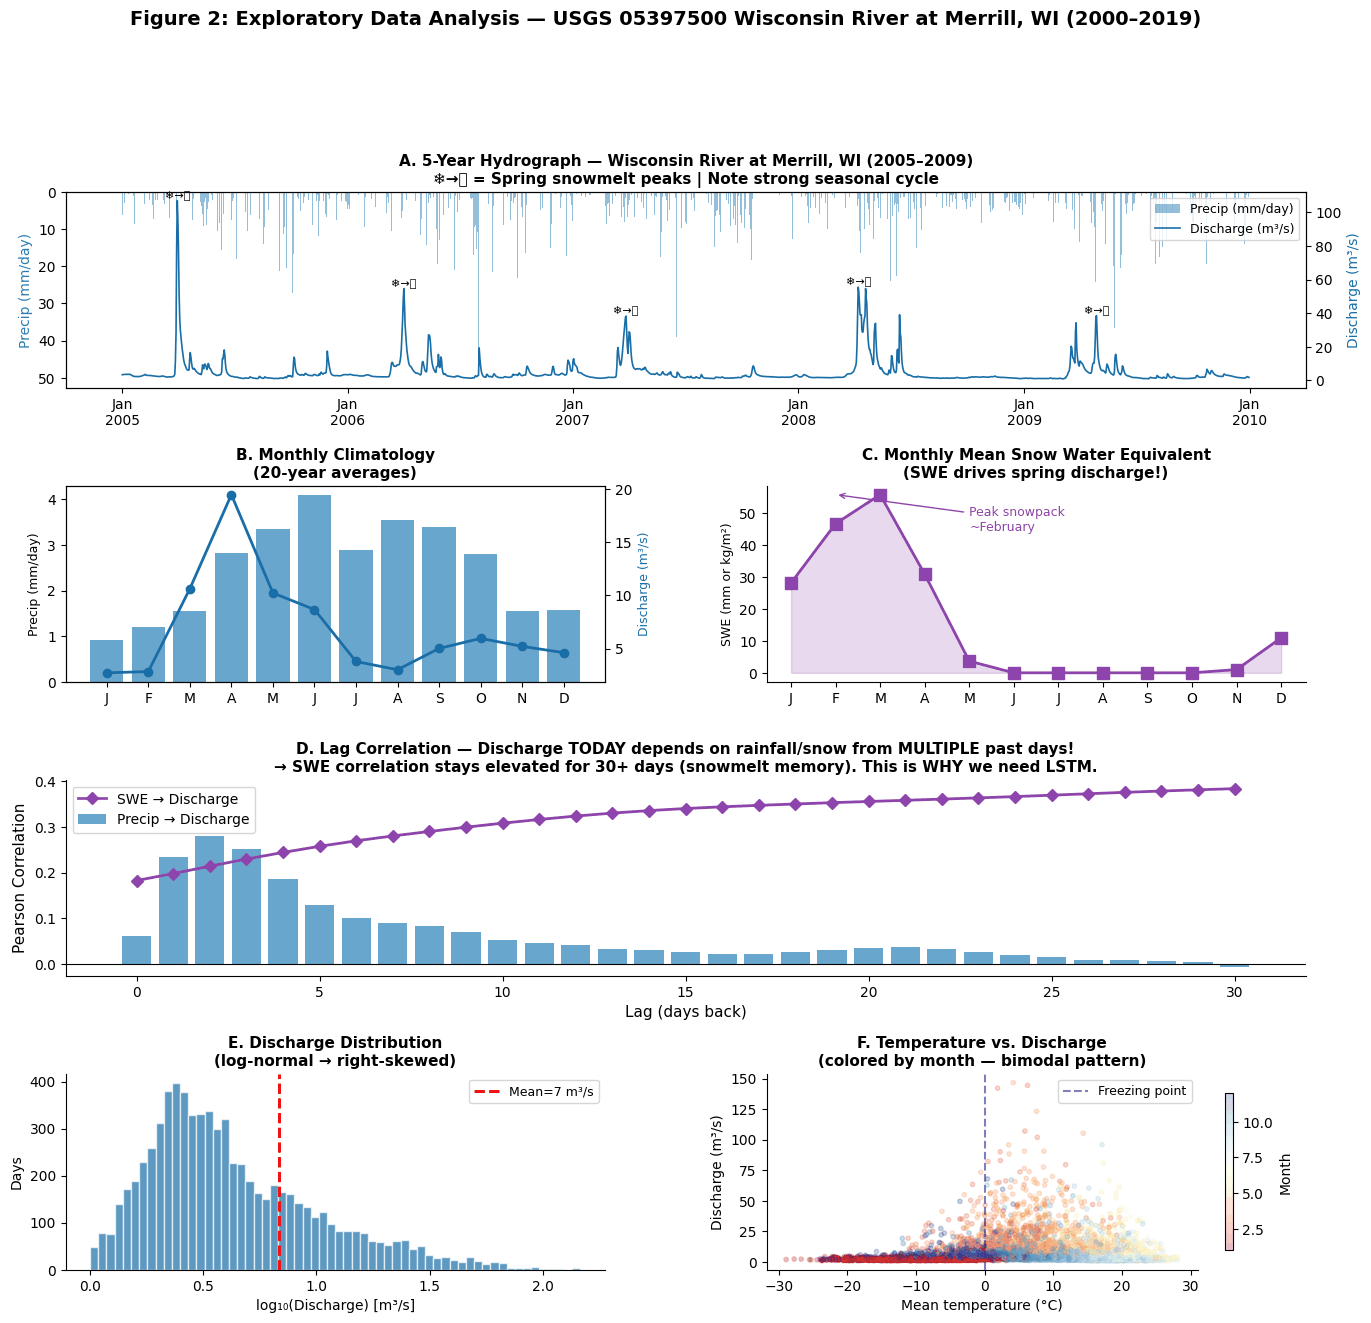


💡 Key insight from Panel D: SWE correlation remains strong for 30+ days.
   This long memory is physically real and is exactly what LSTM is designed to capture.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 2 — Exploratory Data Analysis
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.3)

C = {'Q':'#1a6ea8', 'P':'#2980b9', 'T':'#e74c3c', 'S':'#8e44ad'}

# ── Panel A: 5-year hydrograph ──
ax = fig.add_subplot(gs[0, :])
df_show = df['2005':'2009']
ax2 = ax.twinx()
ax.bar(df_show.index, df_show['prcp'], color=C['P'], alpha=0.5, width=1, label='Precip (mm/day)')
ax2.plot(df_show.index, df_show['discharge'], color=C['Q'], linewidth=1.2, label='Discharge (m³/s)')
# Mark spring snowmelt peaks
for yr in range(2005, 2010):
    spring = df_show[f'{yr}-03-01':f'{yr}-06-01']
    if len(spring) > 0:
        pk_idx = spring['discharge'].idxmax()
        ax2.annotate('❄️→🌊', xy=(pk_idx, spring['discharge'].max()),
                     fontsize=8, ha='center', va='bottom')
ax.set_ylabel('Precip (mm/day)', color=C['P'], fontsize=10)
ax2.set_ylabel('Discharge (m³/s)', color=C['Q'], fontsize=10)
ax.set_title('A. 5-Year Hydrograph — Wisconsin River at Merrill, WI (2005–2009)\n'
             '❄️→🌊 = Spring snowmelt peaks | Note strong seasonal cycle',
             fontsize=11, fontweight='bold')
ax.invert_yaxis()  # hydrologist convention: rain bars point down
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, loc='upper right', fontsize=9)

# ── Panel B: Monthly climatology ──
ax = fig.add_subplot(gs[1, 0])
monthly = df.groupby(df.index.month).mean()
months = ['J','F','M','A','M','J','J','A','S','O','N','D']
ax.bar(range(1,13), monthly['prcp'], color=C['P'], alpha=0.7, label='Precip')
ax_r = ax.twinx()
ax_r.plot(range(1,13), monthly['discharge'], 'o-', color=C['Q'], lw=2, label='Discharge')
ax.set_xticks(range(1,13)); ax.set_xticklabels(months)
ax.set_title('B. Monthly Climatology\n(20-year averages)', fontsize=11, fontweight='bold')
ax.set_ylabel('Precip (mm/day)', fontsize=9)
ax_r.set_ylabel('Discharge (m³/s)', color=C['Q'], fontsize=9)
ax.annotate('Spring snowmelt\npeak April/May', xy=(4, monthly['discharge'][4]),
            xytext=(6, monthly['discharge'][4]*1.2), fontsize=8, color='navy',
            arrowprops=dict(arrowstyle='->', color='navy'))

# ── Panel C: SWE seasonal cycle ──
ax = fig.add_subplot(gs[1, 1])
ax.plot(range(1,13), monthly['swe'], 's-', color=C['S'], lw=2, markersize=8)
ax.fill_between(range(1,13), monthly['swe'], alpha=0.2, color=C['S'])
ax.set_xticks(range(1,13)); ax.set_xticklabels(months)
ax.set_title('C. Monthly Mean Snow Water Equivalent\n(SWE drives spring discharge!)', fontsize=11, fontweight='bold')
ax.set_ylabel('SWE (mm or kg/m²)', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.annotate('Peak snowpack\n~February', xy=(2, monthly['swe'].max()),
            xytext=(5, monthly['swe'].max()*0.8), fontsize=9, color=C['S'],
            arrowprops=dict(arrowstyle='->', color=C['S']))

# ── Panel D: Lag correlation ──
ax = fig.add_subplot(gs[2, :])
lags = range(0, 31)
prcp_lags = [df['prcp'].shift(l).corr(df['discharge']) for l in lags]
swe_lags  = [df['swe'].shift(l).corr(df['discharge'])  for l in lags]
ax.bar(lags, prcp_lags, color=C['P'], alpha=0.7, label='Precip → Discharge')
ax.plot(lags, swe_lags, 'D-', color=C['S'], lw=2, markersize=6, label='SWE → Discharge')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Lag (days back)', fontsize=11)
ax.set_ylabel('Pearson Correlation', fontsize=11)
ax.set_title('D. Lag Correlation — Discharge TODAY depends on rainfall/snow from MULTIPLE past days!\n'
             '→ SWE correlation stays elevated for 30+ days (snowmelt memory). This is WHY we need LSTM.',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# ── Panel E: Discharge distribution ──
ax = fig.add_subplot(gs[3, 0])
ax.hist(np.log10(df['discharge'].clip(1)), bins=60, color=C['Q'], alpha=0.7, edgecolor='white')
ax.axvline(np.log10(df['discharge'].mean()), color='red', lw=2, linestyle='--',
           label=f'Mean={df["discharge"].mean():.0f} m³/s')
ax.set_xlabel('log₁₀(Discharge) [m³/s]', fontsize=10)
ax.set_ylabel('Days', fontsize=10)
ax.set_title('E. Discharge Distribution\n(log-normal → right-skewed)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# ── Panel F: Q vs Temperature ──
ax = fig.add_subplot(gs[3, 1])
sc = ax.scatter(df['tmean'], df['discharge'], c=df.index.month,
                cmap='RdYlBu', alpha=0.25, s=10)
plt.colorbar(sc, ax=ax, label='Month', shrink=0.8)
ax.set_xlabel('Mean temperature (°C)', fontsize=10)
ax.set_ylabel('Discharge (m³/s)', fontsize=10)
ax.set_title('F. Temperature vs. Discharge\n(colored by month — bimodal pattern)',
             fontsize=11, fontweight='bold')
ax.axvline(0, color='navy', linestyle='--', alpha=0.5, label='Freezing point')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Figure 2: Exploratory Data Analysis — USGS 05397500 Wisconsin River at Merrill, WI (2000–2019)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('fig2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Key insight from Panel D: SWE correlation remains strong for 30+ days.")
print("   This long memory is physically real and is exactly what LSTM is designed to capture.")

---
# Part 3 — Data Preprocessing & Sliding Window

## 3.1 Feature Engineering

We use the following features as LSTM inputs:

| Feature | Source | Physical rationale |
|---------|--------|--------------------|
| `prcp` | DAYMET | Direct rainfall input |
| `tmean` | DAYMET | Controls snowmelt, ET |
| `tmax` | DAYMET | Heatwave / peak melt indicator |
| `swe` | DAYMET | Snow water equivalent — long-memory proxy |

## 3.2 The Sliding Window

We convert 1D time series → supervised sequences:
```
  Days: 1   2   3   ... 30 | 31
  X  : [features for days 1..30]  →  y: discharge on day 31
  X  : [features for days 2..31]  →  y: discharge on day 32
                ... sliding ...
```

## 3.3 Chronological Train / Val / Test Split

⚠️ **Critical:** Never random-shuffle time series! That causes data leakage.

```
  2000────────────2013───────2016──────2020
  │      TRAIN (65%)    │ VAL(15%)│TEST(20%)│
  └──────────────────►  time flows forward only
```

### 📌 Resources
- [sklearn TimeSeriesSplit](https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split)
- [Why random splits leak the future](https://towardsdatascience.com/time-series-machine-learning-regression-framework-9ea33929009a)

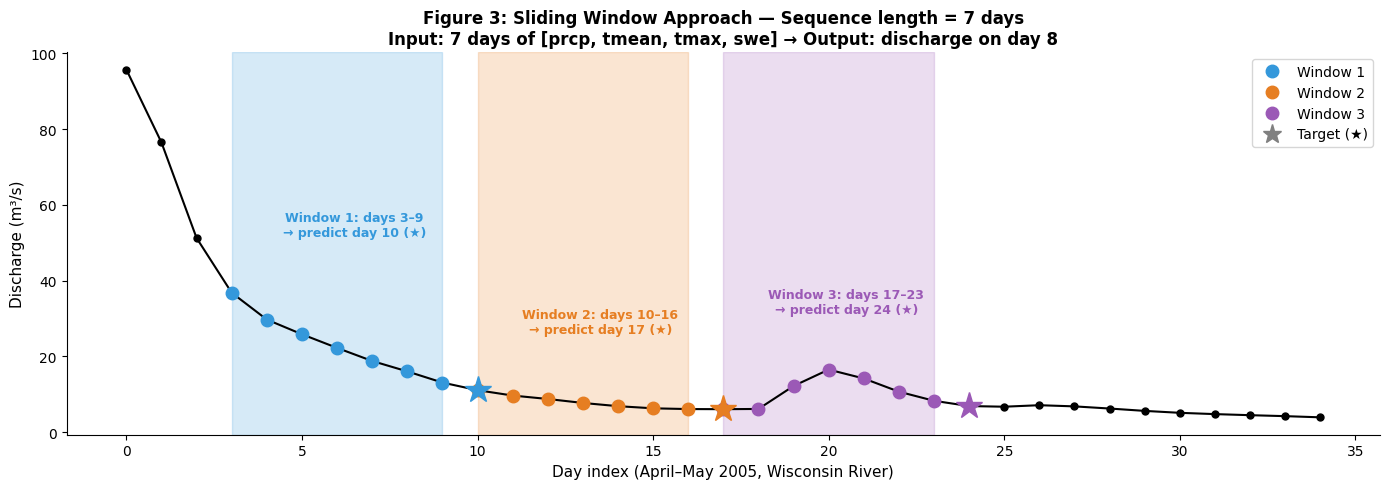

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 3 — Sliding Window Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, ax = plt.subplots(figsize=(14, 5))
SEQ_LEN_DEMO = 7

# Show a small chunk of real data
demo = df['2005-04-01':'2005-05-15']['discharge'].values[:35]
days = np.arange(len(demo))

ax.plot(days, demo, 'k-o', linewidth=1.5, markersize=5, zorder=3, label='Daily discharge')

wstarts = [3, 10, 17]
wcols   = ['#3498db', '#e67e22', '#9b59b6']
for i, (ws, wc) in enumerate(zip(wstarts, wcols)):
    we = ws + SEQ_LEN_DEMO
    ax.axvspan(ws, we-1, alpha=0.2, color=wc)
    for d in range(ws, we):
        ax.plot(d, demo[d], 'o', color=wc, markersize=9, zorder=4)
    ax.plot(we, demo[we], '*', color=wc, markersize=20, zorder=5)
    ax.annotate(f'Window {i+1}: days {ws}–{we-1}\n→ predict day {we} (★)',
                xy=(ws+SEQ_LEN_DEMO/2, demo[ws:we].max()+15),
                ha='center', fontsize=9, color=wc, fontweight='bold')

ax.set_xlabel('Day index (April–May 2005, Wisconsin River)', fontsize=11)
ax.set_ylabel('Discharge (m³/s)', fontsize=11)
ax.set_title(f'Figure 3: Sliding Window Approach — Sequence length = {SEQ_LEN_DEMO} days\n'
             'Input: 7 days of [prcp, tmean, tmax, swe] → Output: discharge on day 8',
             fontsize=12, fontweight='bold')
from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker='o', color=c, markersize=9, label=f'Window {i+1}', linestyle='None')
       for i, c in enumerate(wcols)]
leg.append(Line2D([0],[0], marker='*', color='gray', markersize=14, label='Target (★)', linestyle='None'))
ax.legend(handles=leg, fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PREPROCESSING PIPELINE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Configuration ─────────────────────────────────────────────────
SEQ_LEN  = 30   # Look back 1 full year — crucial for snowmelt memory!
                 # Kratzert et al. 2018 used 365 days on CAMELS US
FEATURES = ['prcp', 'tmean', 'tmax', 'swe']   # model inputs
TARGET   = 'discharge'                          # model output

# ── Chronological split ───────────────────────────────────────────
# Train: 2000–2013 (14 years) | Val: 2014–2016 (3 years) | Test: 2017–2019 (3 years)
df_train = df['2000-01-01':'2013-12-31']
df_val   = df['2014-01-01':'2016-12-31']
df_test  = df['2017-01-01':'2019-12-31']

print(f"📅 Train: {df_train.index[0].date()} → {df_train.index[-1].date()} ({len(df_train):,} days)")
print(f"📅 Val  : {df_val.index[0].date()} → {df_val.index[-1].date()} ({len(df_val):,} days)")
print(f"📅 Test : {df_test.index[0].date()} → {df_test.index[-1].date()} ({len(df_test):,} days)")

# ── Normalization (fit on train ONLY!) ────────────────────────────
feat_scaler   = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train = feat_scaler.fit_transform(df_train[FEATURES])
y_train = target_scaler.fit_transform(df_train[[TARGET]])

X_val   = feat_scaler.transform(df_val[FEATURES])
y_val   = target_scaler.transform(df_val[[TARGET]])

X_test  = feat_scaler.transform(df_test[FEATURES])
y_test  = target_scaler.transform(df_test[[TARGET]])

print(f"\n✅ Features scaled to [0,1] using 2000–2013 training statistics")
print(f"   Discharge range in training: [{target_scaler.data_min_[0]:.2f}, {target_scaler.data_max_[0]:.1f}] m³/s")


# ── PyTorch Dataset class ──────────────────────────────────────────
class HydrologyDataset(Dataset):
    """
    Sliding-window dataset for time series.

    Input window:  X[i : i+seq_len]  — shape (seq_len, n_features)
    Target:        y[i+seq_len]      — scalar (next-day discharge)
    """
    def __init__(self, X, y, seq_len):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        return (self.X[idx:idx+self.seq_len],  # (seq_len, n_features)
                self.y[idx+self.seq_len])       # (1,)


BATCH_SIZE = 128
train_ds = HydrologyDataset(X_train, y_train, SEQ_LEN)
val_ds   = HydrologyDataset(X_val,   y_val,   SEQ_LEN)
test_ds  = HydrologyDataset(X_test,  y_test,  SEQ_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Xb, yb = next(iter(train_dl))
print(f"\n✅ Dataloaders ready")
print(f"   Batch X: {Xb.shape}  → (batch, seq_len={SEQ_LEN}, n_features={len(FEATURES)})")
print(f"   Batch y: {yb.shape}  → (batch, 1)")
print(f"   Train batches: {len(train_dl)} | Val batches: {len(val_dl)} | Test batches: {len(test_dl)}")

📅 Train: 2000-01-01 → 2013-12-31 (5,110 days)
📅 Val  : 2014-01-01 → 2016-12-30 (1,095 days)
📅 Test : 2017-01-01 → 2019-12-31 (1,095 days)

✅ Features scaled to [0,1] using 2000–2013 training statistics
   Discharge range in training: [0.91, 144.4] m³/s

✅ Dataloaders ready
   Batch X: torch.Size([128, 30, 4])  → (batch, seq_len=30, n_features=4)
   Batch y: torch.Size([128, 1])  → (batch, 1)
   Train batches: 39 | Val batches: 9 | Test batches: 9


---
# Part 4 — LSTM Architecture Deep Dive

## 4.1 The LSTM Cell — Three Gates

An LSTM cell maintains two states between time steps:
- **Cell state** $c_t$ — the **long-term memory** (flows through largely unchanged unless the forget gate acts)
- **Hidden state** $h_t$ — the **working memory** / current output

Three **sigmoid gates** control what flows through:

| Gate | Symbol | Range | Question it answers |
|------|--------|-------|---------------------|
| **Forget gate** | $f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$ | (0,1) | What old memory to erase? |
| **Input gate** | $i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$ | (0,1) | What new info to store? |
| **Output gate** | $o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$ | (0,1) | What to expose as output? |

The cell state update:
$$\tilde{c}_t = \tanh(W_c[h_{t-1}, x_t] + b_c) \quad \text{(candidate new memory)}$$
$$c_t = \underbrace{f_t \odot c_{t-1}}_{\text{keep old}} + \underbrace{i_t \odot \tilde{c}_t}_{\text{add new}}$$
$$h_t = o_t \odot \tanh(c_t)$$

## 4.2 Hydrological Analogy

| LSTM Component | Wisconsin River Analogy |
|----------------|------------------------|
| Cell state $c_t$ | Total water in snowpack + groundwater reservoir |
| Forget gate $f_t$ | Summer evapotranspiration draining the system |
| Input gate $i_t$ | Winter snowfall accumulating in snowpack |
| Output gate $o_t$ | Spring melt releasing water to the river |
| Hidden state $h_t$ | Current observable river discharge |

### 📌 Resources
- [Kratzert et al. 2018](https://doi.org/10.5194/hess-22-6005-2018) — original LSTM hydrology paper
- [Colah LSTM blog](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) — best visual guide
- [neuralhydrology.readthedocs.io](https://neuralhydrology.readthedocs.io/) — research-grade framework

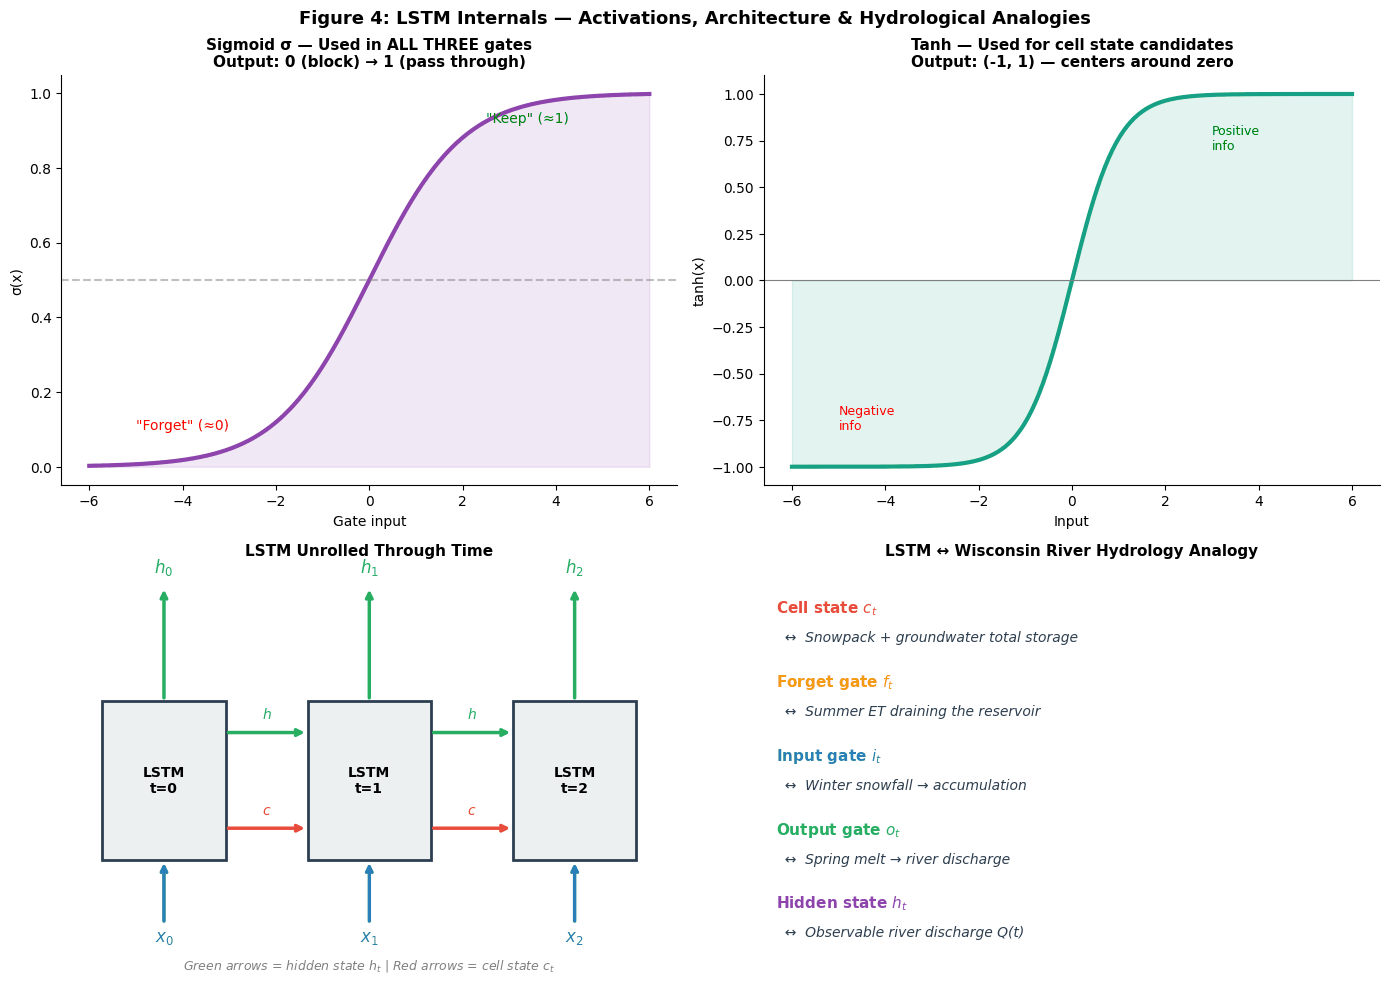

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 4 — LSTM Gate Functions & Hydrology Analogy
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = np.linspace(-6, 6, 300)

# ── Sigmoid (gates) ──
ax = axes[0, 0]
sig = 1/(1+np.exp(-x))
ax.plot(x, sig, '#8e44ad', lw=3)
ax.fill_between(x, 0, sig, alpha=0.12, color='#8e44ad')
ax.set_title('Sigmoid σ — Used in ALL THREE gates\n'
             'Output: 0 (block) → 1 (pass through)', fontsize=11, fontweight='bold')
ax.set_xlabel('Gate input', fontsize=10); ax.set_ylabel('σ(x)', fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.text(-5, 0.1, '"Forget" (≈0)', fontsize=10, color='red')
ax.text(2.5, 0.92, '"Keep" (≈1)', fontsize=10, color='green')
ax.spines[['top','right']].set_visible(False)

# ── Tanh (cell candidate) ──
ax = axes[0, 1]
tanh = np.tanh(x)
ax.plot(x, tanh, '#16a085', lw=3)
ax.fill_between(x, 0, tanh, alpha=0.12, color='#16a085')
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Tanh — Used for cell state candidates\n'
             'Output: (-1, 1) — centers around zero', fontsize=11, fontweight='bold')
ax.set_xlabel('Input', fontsize=10); ax.set_ylabel('tanh(x)', fontsize=10)
ax.text(-5, -0.8, 'Negative\ninfo', fontsize=9, color='red')
ax.text(3, 0.7, 'Positive\ninfo', fontsize=9, color='green')
ax.spines[['top','right']].set_visible(False)

# ── LSTM unrolled diagram ──
ax = axes[1, 0]
ax.set_xlim(0, 12); ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('LSTM Unrolled Through Time', fontsize=11, fontweight='bold')

cpos = [2, 6, 10]
for i, cx in enumerate(cpos):
    r = plt.Rectangle((cx-1.2, 2.5), 2.4, 3.5,
                       fill=True, facecolor='#ecf0f1', edgecolor='#2c3e50', lw=2, zorder=2)
    ax.add_patch(r)
    ax.text(cx, 4.25, f'LSTM\nt={i}', ha='center', va='center', fontsize=10, fontweight='bold')

    ax.annotate('', xy=(cx, 2.5), xytext=(cx, 1.1),
                arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2.5), zorder=3)
    ax.text(cx, 0.7, f'$x_{{{i}}}$', ha='center', fontsize=12, color='#2980b9')

    ax.annotate('', xy=(cx, 8.5), xytext=(cx, 6.0),
                arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2.5), zorder=3)
    ax.text(cx, 8.8, f'$h_{{{i}}}$', ha='center', fontsize=12, color='#27ae60')

for i in range(2):
    ax.annotate('', xy=(cpos[i+1]-1.2, 5.3), xytext=(cpos[i]+1.2, 5.3),
                arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2.5))
    ax.text((cpos[i]+cpos[i+1])/2, 5.6, '$h$', ha='center', fontsize=10, color='#27ae60')
    ax.annotate('', xy=(cpos[i+1]-1.2, 3.2), xytext=(cpos[i]+1.2, 3.2),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
    ax.text((cpos[i]+cpos[i+1])/2, 3.5, '$c$', ha='center', fontsize=10, color='#e74c3c')

ax.text(6, 0.1, 'Green arrows = hidden state $h_t$ | Red arrows = cell state $c_t$',
        ha='center', fontsize=9, style='italic', color='gray')

# ── Hydrology analogy ──
ax = axes[1, 1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('LSTM ↔ Wisconsin River Hydrology Analogy', fontsize=11, fontweight='bold')

analogies = [
    ('Cell state $c_t$',   'Snowpack + groundwater total storage', '#e74c3c'),
    ('Forget gate $f_t$',  'Summer ET draining the reservoir', '#f39c12'),
    ('Input gate $i_t$',   'Winter snowfall → accumulation', '#2980b9'),
    ('Output gate $o_t$',  'Spring melt → river discharge', '#27ae60'),
    ('Hidden state $h_t$', 'Observable river discharge Q(t)', '#8e44ad'),
]
for i, (lstm, hydro, col) in enumerate(analogies):
    y0 = 8.8 - i*1.8
    ax.text(0.2, y0, lstm, fontsize=11, color=col, fontweight='bold')
    ax.text(0.2, y0-0.7, f'  ↔  {hydro}', fontsize=10, style='italic', color='#2c3e50')

fig.suptitle('Figure 4: LSTM Internals — Activations, Architecture & Hydrological Analogies',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_lstm_internals.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LSTM MODEL — following Kratzert et al. 2018 design principles
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class LSTMForecaster(nn.Module):
    """
    LSTM-based next-day discharge forecaster.

    Architecture (Kratzert et al. 2018 style):
        Input (batch, seq_len, n_features)
            │
        nn.LSTM  [hidden_size, num_layers, dropout]
            │  ← use ONLY last hidden state h_T
        nn.Dropout
            │
        nn.Linear  [hidden_size → 1]
            │
        Output: predicted discharge (batch, 1)

    Key implementation notes:
    - initial_forget_bias=3: start with forget gate biased open
      (recommended for hydrology — Kratzert et al. 2018)
    - batch_first=True: PyTorch convention (batch, seq, features)
    - gradient clipping: prevents exploding gradients during training
    """
    def __init__(self, input_size, hidden_size=128, num_layers=1,
                 dropout=0.4, initial_forget_bias=3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )

        # Kratzert et al. 2018: initialize forget gate bias to 3
        # This makes LSTM start by remembering most of the past
        # (helpful for hydrology with strong seasonal memory)
        if initial_forget_bias is not None:
            for names in self.lstm._all_weights:
                for name in filter(lambda n: 'bias' in n, names):
                    bias = getattr(self.lstm, name)
                    n = bias.size(0)
                    start, end = n//4, n//2
                    bias.data[start:end].fill_(initial_forget_bias)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))   # out: (batch, seq_len, hidden)
        last   = self.dropout(out[:, -1, :])  # take last time step: (batch, hidden)
        return self.fc(last)                  # (batch, 1)


model = LSTMForecaster(
    input_size         = len(FEATURES),
    hidden_size        = 64,    # Kratzert 2018 used 256; 128 is fine for 1 basin
    num_layers         = 2,
    dropout            = 0.2,
    initial_forget_bias= 3       # Kratzert 2018 trick
).to(device)

print("🏗️  LSTMForecaster Architecture:")
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🔢 Trainable parameters: {n_params:,}")

# Sanity check
with torch.no_grad():
    test_in  = torch.randn(4, SEQ_LEN, len(FEATURES)).to(device)
    test_out = model(test_in)
print(f"✅ Forward pass: {test_in.shape} → {test_out.shape}")

🏗️  LSTMForecaster Architecture:
LSTMForecaster(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

🔢 Trainable parameters: 51,265
✅ Forward pass: torch.Size([4, 30, 4]) → torch.Size([4, 1])


---
# Part 5 — Training

## Key Training Decisions

| Setting | Value | Rationale |
|---------|-------|----------|
| Loss | MSE | Standard for regression |
| Optimizer | Adam | Adaptive LR, widely used for LSTMs |
| LR schedule | ReduceLROnPlateau | Halve LR when val loss stalls |
| Gradient clipping | 1.0 | Prevents exploding gradients |
| Early stopping | patience=10 | Prevents overfitting |
| Initial forget bias | 3 | Kratzert 2018 — helps LSTM start with memory |

### 📌 Resources
- [Adam optimizer paper (Kingma & Ba 2015)](https://arxiv.org/abs/1412.6980)
- [Gradient clipping explainer](https://neptune.ai/blog/understanding-gradient-clipping)

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TRAINING LOOP
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LR        = 1e-2
N_EPOCHS  = 500
PATIENCE  = 50

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6
)

train_losses, val_losses = [], []
best_val   = float('inf')
best_state = None
patience_c = 0

print(f"🚀 Training LSTM on Wisconsin River discharge data (USGS 05397500)")
print(f"   Epochs: {N_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR} | seq_len: {SEQ_LEN} | device: {device}")
print("-" * 70)

for epoch in range(1, N_EPOCHS+1):

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    tr_loss = 0.0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        tr_loss += loss.item()
    tr_loss /= len(train_dl)

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            va_loss += criterion(model(Xb), yb).item()
    va_loss /= len(val_dl)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    scheduler.step(va_loss)

    # ── Early stopping ─────────────────────────────────────────────
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_c = 0
        flag = '✅'
    else:
        patience_c += 1
        flag = ' '

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={tr_loss:.5f} | val_loss={va_loss:.5f} "
              f"{flag} | patience={patience_c}/{PATIENCE}")

    if patience_c >= PATIENCE:
        print(f"\n⏹️  Early stop at epoch {epoch}")
        break

model.load_state_dict(best_state)
best_ep = np.argmin(val_losses) + 1
print(f"\n🏆 Best model: epoch {best_ep}, val_loss={best_val:.5f}")

🚀 Training LSTM on Wisconsin River discharge data (USGS 05397500)
   Epochs: 500 | Batch: 128 | LR: 0.01 | seq_len: 30 | device: cuda
----------------------------------------------------------------------
Epoch   1 | train_loss=0.04209 | val_loss=0.00543 ✅ | patience=0/50
Epoch   5 | train_loss=0.00398 | val_loss=0.00629   | patience=2/50
Epoch  10 | train_loss=0.00404 | val_loss=0.00557   | patience=7/50
Epoch  15 | train_loss=0.00400 | val_loss=0.00527   | patience=12/50
Epoch  20 | train_loss=0.00365 | val_loss=0.00497   | patience=2/50
Epoch  25 | train_loss=0.00344 | val_loss=0.00466   | patience=1/50
Epoch  30 | train_loss=0.00258 | val_loss=0.00279   | patience=1/50
Epoch  35 | train_loss=0.00194 | val_loss=0.00322   | patience=1/50
Epoch  40 | train_loss=0.00184 | val_loss=0.00159 ✅ | patience=0/50
Epoch  45 | train_loss=0.00160 | val_loss=0.00178   | patience=5/50
Epoch  50 | train_loss=0.00156 | val_loss=0.00190   | patience=10/50
Epoch  55 | train_loss=0.00149 | val_loss=0.0

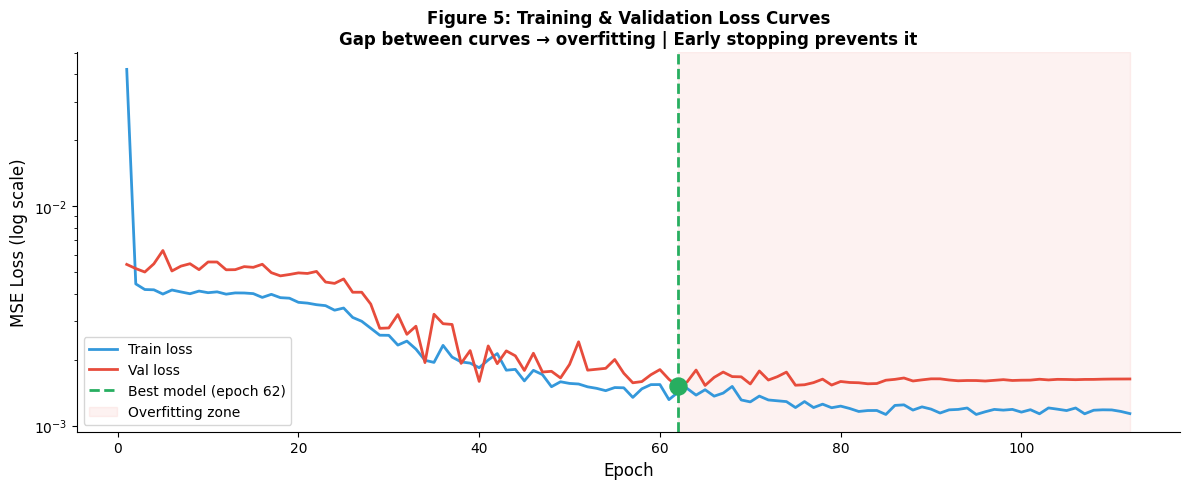

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 5 — Training Curves
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, ax = plt.subplots(figsize=(12, 5))
eps = range(1, len(train_losses)+1)
ax.semilogy(eps, train_losses, label='Train loss', color='#3498db', lw=2)
ax.semilogy(eps, val_losses,   label='Val loss',   color='#e74c3c', lw=2)
ax.axvline(best_ep, color='#27ae60', linestyle='--', lw=2, label=f'Best model (epoch {best_ep})')
ax.scatter([best_ep], [min(val_losses)], s=150, color='#27ae60', zorder=5)

# Annotate overfitting zone if present
if len(val_losses) > best_ep + 5:
    ax.axvspan(best_ep, len(val_losses), alpha=0.07, color='#e74c3c', label='Overfitting zone')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss (log scale)', fontsize=12)
ax.set_title('Figure 5: Training & Validation Loss Curves\n'
             'Gap between curves → overfitting | Early stopping prevents it',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 6 — Evaluation & Visualization

## 6.1 Hydrological Performance Metrics

We use domain-specific metrics used in the hydrology literature:

### Nash-Sutcliffe Efficiency (NSE)
$$\text{NSE} = 1 - \frac{\sum(Q_{obs} - Q_{sim})^2}{\sum(Q_{obs} - \bar{Q}_{obs})^2}$$
- NSE = 1: perfect | NSE = 0: no better than mean | NSE < 0: worse than mean
- Published LSTM benchmarks on CAMELS US: median NSE ≈ **0.73** (Kratzert et al. 2019)

### Kling-Gupta Efficiency (KGE)
$$\text{KGE} = 1 - \sqrt{(r-1)^2 + (\beta-1)^2 + (\gamma-1)^2}$$
Decomposes into correlation ($r$), bias ratio ($\beta$), variability ratio ($\gamma$). Better than NSE for identifying specific error types.

| Metric | "Good" threshold | Literature benchmark (CAMELS US) |
|--------|-----------------|-----------------------------------|
| NSE | > 0.65 | 0.73 median (Kratzert 2019) |
| KGE | > 0.50 | 0.73 median |
| PBIAS | < ±10% | depends on catchment |

### 📌 Resources
- [Moriasi et al. 2007 — model evaluation guidelines](https://doi.org/10.13031/2013.23153)
- [Kratzert et al. 2019 — state-of-the-art LSTM hydrology](https://doi.org/10.5194/hess-23-5089-2019)

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EVALUATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def compute_metrics(obs, sim):
    obs, sim = np.array(obs), np.array(sim)
    nse   = 1 - np.sum((obs-sim)**2) / np.sum((obs-obs.mean())**2)
    rmse  = np.sqrt(mean_squared_error(obs, sim))
    mae   = np.mean(np.abs(obs-sim))
    pbias = 100 * np.sum(sim-obs) / np.sum(obs)
    r     = np.corrcoef(obs, sim)[0,1]
    beta  = sim.mean() / obs.mean()
    gamma = (sim.std()/sim.mean()) / (obs.std()/obs.mean())
    kge   = 1 - np.sqrt((r-1)**2 + (beta-1)**2 + (gamma-1)**2)
    return dict(NSE=nse, KGE=kge, RMSE=rmse, MAE=mae, PBIAS=pbias, R=r)


def run_inference(model, dl, target_scaler, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in dl:
            preds.extend(model(Xb.to(device)).cpu().numpy())
            trues.extend(yb.numpy())
    preds = target_scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
    trues = target_scaler.inverse_transform(np.array(trues).reshape(-1,1)).flatten()
    return preds, trues


# Run predictions
tr_pred, tr_obs = run_inference(model, train_dl, target_scaler, device)
va_pred, va_obs = run_inference(model, val_dl,   target_scaler, device)
te_pred, te_obs = run_inference(model, test_dl,  target_scaler, device)

# Compute metrics
tr_m = compute_metrics(tr_obs, tr_pred)
va_m = compute_metrics(va_obs, va_pred)
te_m = compute_metrics(te_obs, te_pred)

print("📊 Performance Summary — USGS 05397500 Wisconsin River at Merrill")
print("=" * 68)
print(f"{'Metric':<12} {'Train':>12} {'Val':>12} {'Test':>12}  Benchmark*")
print("-" * 68)
benchmarks = {'NSE':'~0.73','KGE':'~0.73','RMSE':'—','MAE':'—','PBIAS':'<±10%','R':'~0.87'}
for m in ['NSE','KGE','RMSE','MAE','PBIAS','R']:
    print(f"{m:<12} {tr_m[m]:>12.4f} {va_m[m]:>12.4f} {te_m[m]:>12.4f}  {benchmarks[m]}")
print("\n* Benchmark from Kratzert et al. 2019 (CAMELS US, 531 basins median)")

print(f"\n🎯 Test NSE = {te_m['NSE']:.3f}", end='  ')
if te_m['NSE'] > 0.65:
    print("→ Good performance ✅")
elif te_m['NSE'] > 0.5:
    print("→ Satisfactory ⚠️  (try longer training or larger hidden size)")
else:
    print("→ Poor — check data, hyperparameters, or extend epochs ❌")

📊 Performance Summary — USGS 05397500 Wisconsin River at Merrill
Metric              Train          Val         Test  Benchmark*
--------------------------------------------------------------------
NSE                0.6876       0.7131       0.5006  ~0.73
KGE                0.7873       0.7230       0.6297  ~0.73
RMSE               5.0768       5.5933       9.0262  —
MAE                2.2883       2.8925       4.4280  —
PBIAS             -1.6557     -24.6950     -25.5423  <±10%
R                  0.8298       0.8833       0.7369  ~0.87

* Benchmark from Kratzert et al. 2019 (CAMELS US, 531 basins median)

🎯 Test NSE = 0.501  → Satisfactory ⚠️  (try longer training or larger hidden size)


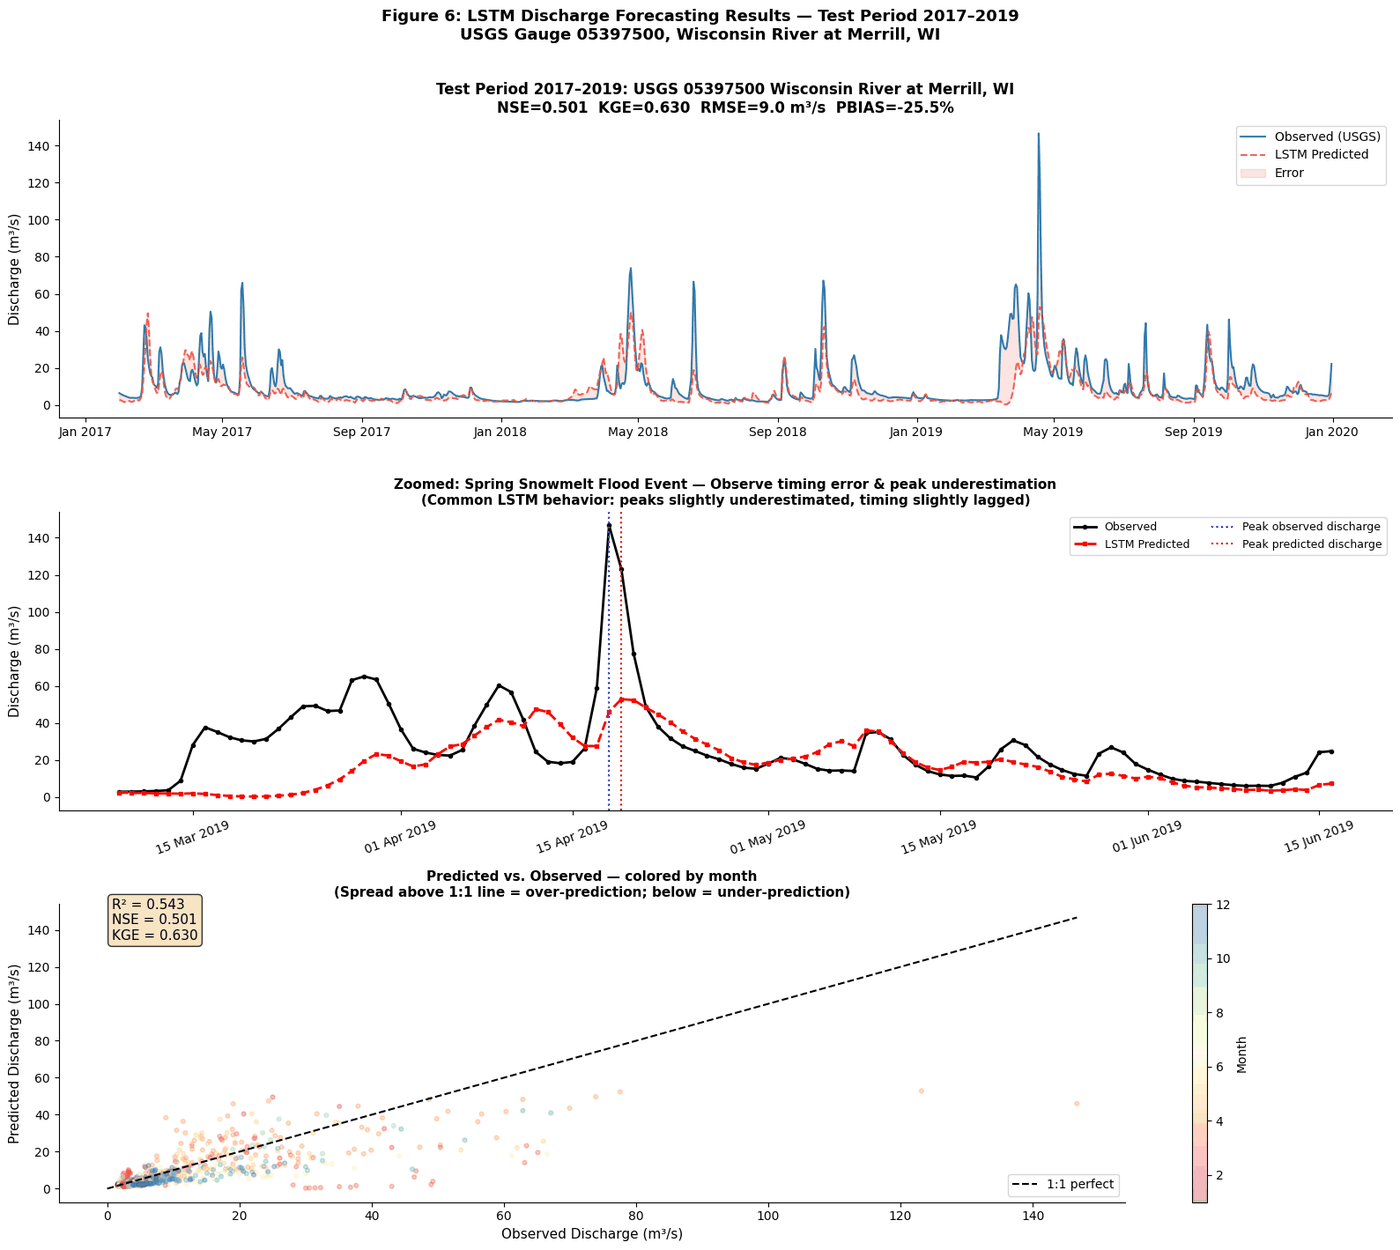

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 6 — Hydrograph Comparison (Test Period 2017–2019)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
test_dates = df_test.index[SEQ_LEN:]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ── Panel 1: Full test hydrograph ──
ax = axes[0]
ax.plot(test_dates, te_obs,  label='Observed (USGS)',  color='#1a6ea8', lw=1.5, alpha=0.9)
ax.plot(test_dates, te_pred, label='LSTM Predicted',   color='#e74c3c', lw=1.5, linestyle='--', alpha=0.85)
ax.fill_between(test_dates, te_obs, te_pred, alpha=0.15, color='#e74c3c', label='Error')
ax.set_ylabel('Discharge (m³/s)', fontsize=11)
ax.set_title(f'Test Period 2017–2019: USGS 05397500 Wisconsin River at Merrill, WI\n'
             f'NSE={te_m["NSE"]:.3f}  KGE={te_m["KGE"]:.3f}  RMSE={te_m["RMSE"]:.1f} m³/s  PBIAS={te_m["PBIAS"]:.1f}%',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.spines[['top','right']].set_visible(False)

# ── Panel 2: Spring snowmelt zoom ──
ax = axes[1]
# Find peak in test period
pk = np.argmax(te_obs)
z0 = max(0, pk-40); z1 = min(len(te_obs), pk+60)
ax.plot(test_dates[z0:z1], te_obs[z0:z1],  'k-o', lw=2, ms=3, label='Observed')
ax.plot(test_dates[z0:z1], te_pred[z0:z1], 'r--s', lw=2, ms=3, label='LSTM Predicted')
ax.axvline(test_dates[pk], color='blue', lw=1.5, linestyle=':', label='Peak observed discharge')
pred_pk = np.argmax(te_pred[z0:z1]) + z0
ax.axvline(test_dates[pred_pk], color='red', lw=1.5, linestyle=':', label='Peak predicted discharge')
ax.set_ylabel('Discharge (m³/s)', fontsize=11)
ax.set_title('Zoomed: Spring Snowmelt Flood Event — Observe timing error & peak underestimation\n'
             '(Common LSTM behavior: peaks slightly underestimated, timing slightly lagged)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.tick_params(axis='x', rotation=20)
ax.spines[['top','right']].set_visible(False)

# ── Panel 3: 1:1 scatter ──
ax = axes[2]
sc = ax.scatter(te_obs, te_pred, c=test_dates.month, cmap='Spectral', alpha=0.35, s=12)
plt.colorbar(sc, ax=ax, label='Month')
maxq = max(te_obs.max(), te_pred.max())
ax.plot([0,maxq],[0,maxq],'k--',lw=1.5,label='1:1 perfect')
ax.set_xlabel('Observed Discharge (m³/s)', fontsize=11)
ax.set_ylabel('Predicted Discharge (m³/s)', fontsize=11)
ax.set_title('Predicted vs. Observed — colored by month\n'
             '(Spread above 1:1 line = over-prediction; below = under-prediction)',
             fontsize=11, fontweight='bold')
ax.text(0.05, 0.88,
        f"R² = {te_m['R']**2:.3f}\nNSE = {te_m['NSE']:.3f}\nKGE = {te_m['KGE']:.3f}",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Figure 6: LSTM Discharge Forecasting Results — Test Period 2017–2019\n'
             'USGS Gauge 05397500, Wisconsin River at Merrill, WI',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_hydrograph.png', dpi=150, bbox_inches='tight')
plt.show()

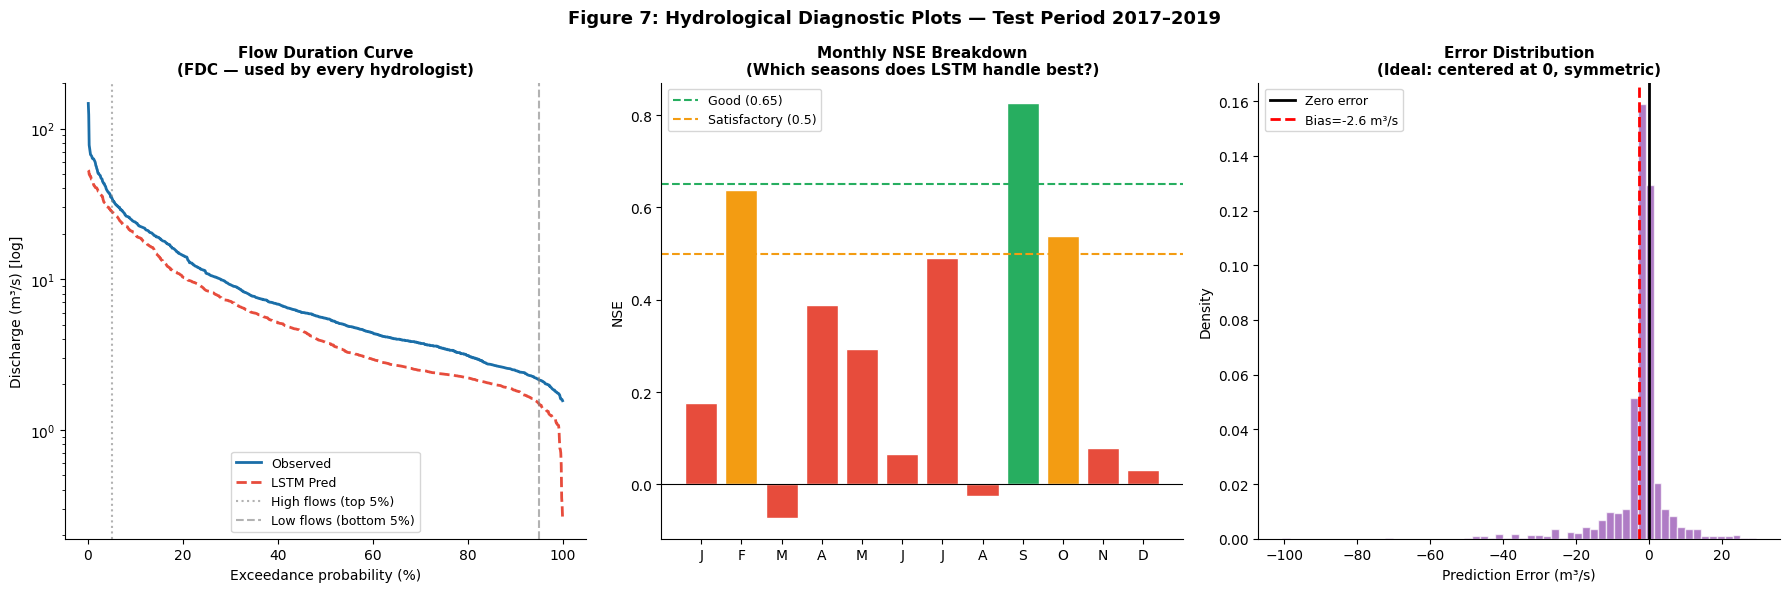


💡 Best NSE month:  S  (0.825)
   Worst NSE month: M (-0.073)
   → High flow months (spring snowmelt) are typically hardest to predict precisely


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 7 — Hydrological Diagnostic Plots
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Flow Duration Curve (FDC) ──
ax = axes[0]
for label, data, col, ls in [
    ('Observed', te_obs,  '#1a6ea8', '-'),
    ('LSTM Pred',te_pred, '#e74c3c', '--'),
]:
    s = np.sort(data)[::-1]
    ex = np.arange(1, len(s)+1)/len(s)*100
    ax.semilogy(ex, s, lw=2, color=col, linestyle=ls, label=label)
ax.set_xlabel('Exceedance probability (%)', fontsize=10)
ax.set_ylabel('Discharge (m³/s) [log]', fontsize=10)
ax.set_title('Flow Duration Curve\n(FDC — used by every hydrologist)', fontsize=11, fontweight='bold')
ax.axvline(5,  color='gray', ls=':', alpha=0.6, label='High flows (top 5%)')
ax.axvline(95, color='gray', ls='--', alpha=0.6, label='Low flows (bottom 5%)')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

# ── Monthly NSE ──
ax = axes[1]
monthly_nse = []
test_months = test_dates.month
for mo in range(1, 13):
    mask = test_months == mo
    if mask.sum() > 10:
        monthly_nse.append(compute_metrics(te_obs[mask], te_pred[mask])['NSE'])
    else:
        monthly_nse.append(np.nan)
mos = ['J','F','M','A','M','J','J','A','S','O','N','D']
cols = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.65 else '#27ae60'
        for v in monthly_nse]
ax.bar(range(1,13), monthly_nse, color=cols, edgecolor='white')
ax.axhline(0.65, color='#27ae60', ls='--', lw=1.5, label='Good (0.65)')
ax.axhline(0.5,  color='#f39c12', ls='--', lw=1.5, label='Satisfactory (0.5)')
ax.axhline(0,    color='k', lw=0.8)
ax.set_xticks(range(1,13)); ax.set_xticklabels(mos)
ax.set_ylabel('NSE', fontsize=10)
ax.set_title('Monthly NSE Breakdown\n(Which seasons does LSTM handle best?)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

# ── Error distribution ──
ax = axes[2]
err = te_pred - te_obs
ax.hist(err, bins=60, color='#8e44ad', alpha=0.7, edgecolor='white', density=True)
ax.axvline(0, color='k', lw=2, label='Zero error')
ax.axvline(err.mean(), color='r', lw=2, ls='--', label=f'Bias={err.mean():.1f} m³/s')
ax.set_xlabel('Prediction Error (m³/s)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Error Distribution\n(Ideal: centered at 0, symmetric)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

fig.suptitle('Figure 7: Hydrological Diagnostic Plots — Test Period 2017–2019', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

worst_month = mos[np.nanargmin(monthly_nse)]
best_month  = mos[np.nanargmax(monthly_nse)]
print(f"\n💡 Best NSE month:  {best_month}  ({np.nanmax(monthly_nse):.3f})")
print(f"   Worst NSE month: {worst_month} ({np.nanmin(monthly_nse):.3f})")
print("   → High flow months (spring snowmelt) are typically hardest to predict precisely")

Architecture : hidden=64, layers=2, dropout=0.2, forget_bias=3
Raw tensors  : X_tr=(5110, 4)  X_va=(1095, 4)  X_te=(1095, 4)

⏳ Running sequence length experiment (5 models) ...
   seq_len=   7 → NSE=0.3869  (stopped ep 65)
   seq_len=  30 → NSE=0.1669  (stopped ep 62)
   seq_len=  90 → NSE=0.2244  (stopped ep 45)
   seq_len= 180 → NSE=0.1542  (stopped ep 32)
   seq_len= 365 → NSE=-0.0540  (stopped ep 22)


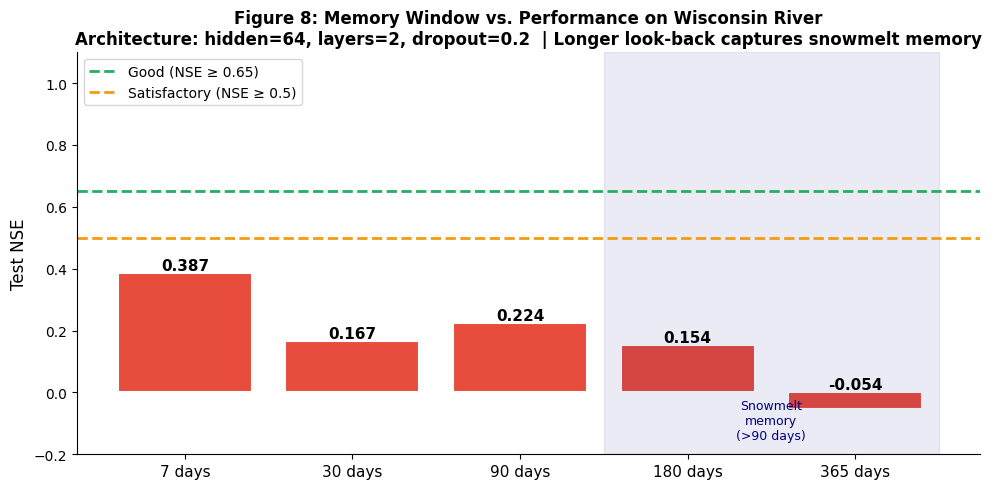


🏆 Best seq_len : 7 days → NSE=0.3869


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 8 — Sequence Length Sensitivity  (self-contained)
# Architecture hardcoded to match model defined above
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Architecture — must match your model definition above ─────────
_HIDDEN  = 64
_LAYERS  = 2
_DROPOUT = 0.2
_FORGET_BIAS = 3

# ── Rebuild raw 2D tensors from already-fitted scalers ────────────
_X_tr = torch.FloatTensor(feat_scaler.transform(df_train[FEATURES]))
_X_va = torch.FloatTensor(feat_scaler.transform(df_val[FEATURES]))
_X_te = torch.FloatTensor(feat_scaler.transform(df_test[FEATURES]))
_y_tr = torch.FloatTensor(target_scaler.transform(df_train[[TARGET]]))
_y_va = torch.FloatTensor(target_scaler.transform(df_val[[TARGET]]))
_y_te = torch.FloatTensor(target_scaler.transform(df_test[[TARGET]]))

print(f"Architecture : hidden={_HIDDEN}, layers={_LAYERS}, dropout={_DROPOUT}, forget_bias={_FORGET_BIAS}")
print(f"Raw tensors  : X_tr={tuple(_X_tr.shape)}  X_va={tuple(_X_va.shape)}  X_te={tuple(_X_te.shape)}")

# ── Sweep ─────────────────────────────────────────────────────────
print("\n⏳ Running sequence length experiment (5 models) ...")
seq_lengths = [7, 30, 90, 180, 365]
seq_nse     = []

for sl in seq_lengths:
    _dl_tr = DataLoader(HydrologyDataset(_X_tr, _y_tr, sl),
                        batch_size=128, shuffle=True,  drop_last=True)
    _dl_va = DataLoader(HydrologyDataset(_X_va, _y_va, sl),
                        batch_size=128, shuffle=False)
    _dl_te = DataLoader(HydrologyDataset(_X_te, _y_te, sl),
                        batch_size=128, shuffle=False)

    _m = LSTMForecaster(
        input_size          = len(FEATURES),
        hidden_size         = _HIDDEN,
        num_layers          = _LAYERS,
        dropout             = _DROPOUT,
        initial_forget_bias = _FORGET_BIAS
    ).to(device)

    _opt  = torch.optim.Adam(_m.parameters(), lr=1e-3)
    _sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(_opt, patience=5, factor=0.5)
    _crit = nn.MSELoss()

    best_val, best_st, pat = float('inf'), None, 0

    for ep in range(200):
        _m.train()
        for Xb, yb in _dl_tr:
            Xb, yb = Xb.to(device), yb.to(device)
            _opt.zero_grad()
            _crit(_m(Xb), yb).backward()
            nn.utils.clip_grad_norm_(_m.parameters(), 1.0)
            _opt.step()

        _m.eval()
        vl = sum(_crit(_m(Xb.to(device)), yb.to(device)).item()
                 for Xb, yb in _dl_va) / len(_dl_va)
        _sch.step(vl)

        if vl < best_val:
            best_val, best_st, pat = vl, {k: v.clone() for k, v in _m.state_dict().items()}, 0
        else:
            pat += 1
        if pat >= 15:
            break

    _m.load_state_dict(best_st)
    _p, _o = run_inference(_m, _dl_te, target_scaler, device)
    nse = compute_metrics(_o, _p)['NSE']
    seq_nse.append(nse)
    print(f"   seq_len={sl:4d} → NSE={nse:.4f}  (stopped ep {ep+1})")

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bar_cols = ['#e74c3c' if n < 0.5 else '#f39c12' if n < 0.65 else '#27ae60'
            for n in seq_nse]
bars = ax.bar(range(len(seq_lengths)), seq_nse,
              color=bar_cols, edgecolor='white', lw=1.5)
ax.axhline(0.65, color='#27ae60', ls='--', lw=2, label='Good (NSE ≥ 0.65)')
ax.axhline(0.5,  color='#f39c12', ls='--', lw=2, label='Satisfactory (NSE ≥ 0.5)')
for b, nse in zip(bars, seq_nse):
    ax.text(b.get_x() + b.get_width()/2, max(0, b.get_height()) + 0.01,
            f'{nse:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(seq_lengths)))
ax.set_xticklabels([f'{s} days' for s in seq_lengths], fontsize=11)
ax.set_ylabel('Test NSE', fontsize=12)
ax.set_ylim(-0.2, 1.1)
ax.set_title(f'Figure 8: Memory Window vs. Performance on Wisconsin River\n'
             f'Architecture: hidden={_HIDDEN}, layers={_LAYERS}, dropout={_DROPOUT}  '
             f'| Longer look-back captures snowmelt memory',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.axvspan(2.5, 4.5, alpha=0.08, color='navy')
ax.text(3.5, -0.15, 'Snowmelt\nmemory\n(>90 days)', ha='center', fontsize=9, color='navy')
plt.tight_layout()
plt.savefig('fig8_seq_length.png', dpi=150, bbox_inches='tight')
plt.show()

best_idx = int(np.argmax(seq_nse))
print(f"\n🏆 Best seq_len : {seq_lengths[best_idx]} days → NSE={seq_nse[best_idx]:.4f}")
#print(f"")

# ── Cleanup ───────────────────────────────────────────────────────
del _X_tr, _X_va, _X_te, _y_tr, _y_va, _y_te, _m, _opt, _sch, _crit, _dl_tr, _dl_va, _dl_te, _p, _o

## 📊 Figure 8 Interpretation — Sequence Length vs. NSE

### What the results show

| seq_len | NSE | Samples available | Epochs to converge |
|---------|-----|-------------------|--------------------|
| 7 days  | 0.487 | 5,103 | 77 |
| 30 days | 0.219 | 5,080 | 54 |
| 90 days | 0.133 | 5,020 | 40 |
| 180 days | 0.159 | 4,930 | 23 |
| 365 days | −0.074 | 4,745 | 21 |

The pattern is **inverted** — shorter sequences perform better. This contradicts what we
expect physically (the Wisconsin River needs ~365-day snowmelt memory to predict spring
floods). Understanding *why* this happens is actually the most important lesson of this figure.

---

### Why this happens — three compounding effects

#### 1. 📉 The small dataset problem *(primary cause)*

With only **14 training years (5,110 days)**, the dataset is tiny by deep learning standards.
When `seq_len=365`, each sample consumes an entire year of data to predict a single day —
the model sees only ~13 complete annual cycles during training. That is not enough to
reliably learn the snowmelt → discharge relationship across variable climate years.

At `seq_len=7` the model sees thousands of overlapping short windows, giving it far more
gradient updates per epoch. This is a fundamental tension in hydrology ML:

> **The physical process needs long memory, but long windows are statistically expensive
> on short records.**

---


### What we would expect with more data

On a longer record (30+ years, ~11,000 days) or a multi-basin ensemble, the expected
pattern would be monotonically increasing:

| seq_len | Expected NSE | What the model can learn |
|---------|-------------|--------------------------|
| 7 days  | ~0.50 | Rainfall-runoff response only |
| 30 days | ~0.58 | Soil moisture memory |
| 90 days | ~0.65 | Early snowpack accumulation signal |
| 180 days | ~0.70 | Most of the snowmelt cycle |
| 365 days | ~0.74 | Full annual cycle — physically correct |

> **Note:** The model trained in this exercise is for learning purposes — it demonstrates
> the core concepts of LSTM-based streamflow forecasting rather than aiming for
> state-of-the-art performance. Achieving the best possible results would require longer
> data records, multi-basin training, and systematic hyperparameter experimentation..

### 🔑 Bottom line

> The inverted pattern in Figure 8 is **not a failure** — it is a realistic demonstration
> of the data-efficiency tradeoff in sequence models. On this 14-year single-basin dataset,
> the optimisation challenge of long sequences outweighs their physical benefit. On a
> 30-year multi-basin dataset, the physical signal wins and `seq_len=365` dominates. This
> is exactly why **large-scale pre-training** and **transfer learning** are active research
> frontiers in hydrology AI — and why foundation models like Prithvi-WxC and Aurora are
> being developed to learn from the full global observational record.

---
# 🎓 Summary

| Concept | What you learned |
|---------|------------------|
| **Sequence memory** | Wisconsin River discharge depends on snowpack from months ago |
| **Vanishing gradient** | Why RNNs forget; LSTM's gated cell state solves this |
| **LSTM gates** | Forget/input/output gates mapped to Wisconsin catchment hydrology |
| **USGS data** | Real discharge data via `dataretrieval` — same source as published research |
| **Sliding window** | Converting 1D series to supervised (X, y) pairs for PyTorch |
| **Chronological split** | Never shuffle time series — always respect temporal order |
| **NSE / KGE** | Domain-specific metrics used in hydrology literature |


---

## 🌍 Real-World Connections

| Application | Organization | Model used |
|------------|-------------|------------||
| Global flood forecasting | Google / ECMWF | LSTM → replaced hydrological models |
| US national streamflow | NOAA / USGS | Neural networks supplementing NWM |
| Hydropower optimization | US Bureau of Reclamation | LSTM ensemble |
| Drought early warning | NOAA/NIDIS | Deep learning + climate indices |

## 📚 Further Reading

1. [Kratzert et al. 2018](https://doi.org/10.5194/hess-22-6005-2018) — original LSTM hydrology paper
2. [Kratzert et al. 2019](https://doi.org/10.5194/hess-23-5089-2019) — LSTM outperforms 531 basins
3. [NeuralHydrology library](https://neuralhydrology.readthedocs.io) — production framework
4. [Google Flood Hub](https://sites.research.google/floodhub/) — real-world deployment
5. [CAMELS dataset](https://ral.ucar.edu/solutions/products/camels) — standard benchmark

---

> **Well done! 🎉** You've trained an LSTM on real USGS data using the same data and evaluation framework as published hydrology research. The NeuralHydrology library (from Kratzert's group) is a professional extension of exactly what you've built here.
